In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing.csv")

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
#Stating inplce = True means we want to drop the null values and then resave it in the data variable

data.dropna(inplace = True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [7]:
from sklearn.model_selection import train_test_split

#Assigning our x and y values before we split everything into a training and testing datasets
x = data.drop(["median_house_value"], axis = 1)
y = data["median_house_value"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [9]:
#Combining both training datasets together so we can do some exploration
train_data = x_train.join(y_train)

In [10]:
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
18096,-122.04,37.33,26.0,2690.0,401.0,1264.0,429.0,7.7643,<1H OCEAN,474700.0
8481,-118.29,33.93,31.0,3894.0,1017.0,3590.0,962.0,2.0437,<1H OCEAN,137200.0
19348,-122.85,38.62,16.0,4418.0,704.0,1908.0,697.0,4.5913,<1H OCEAN,244600.0
1682,-122.30,38.00,34.0,1712.0,317.0,956.0,341.0,4.4394,NEAR BAY,162000.0
11986,-117.51,34.02,24.0,7779.0,1835.0,3996.0,1765.0,2.1764,INLAND,135300.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

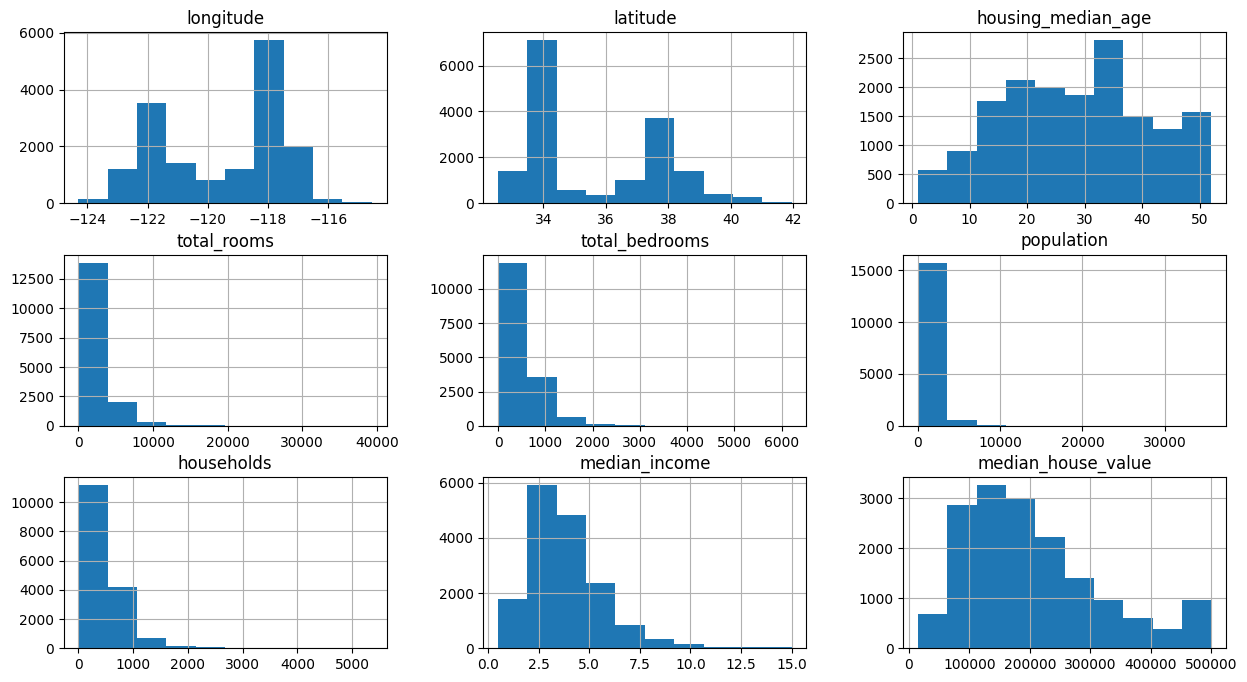

In [11]:
train_data.hist(figsize = (15,8))

<Axes: >

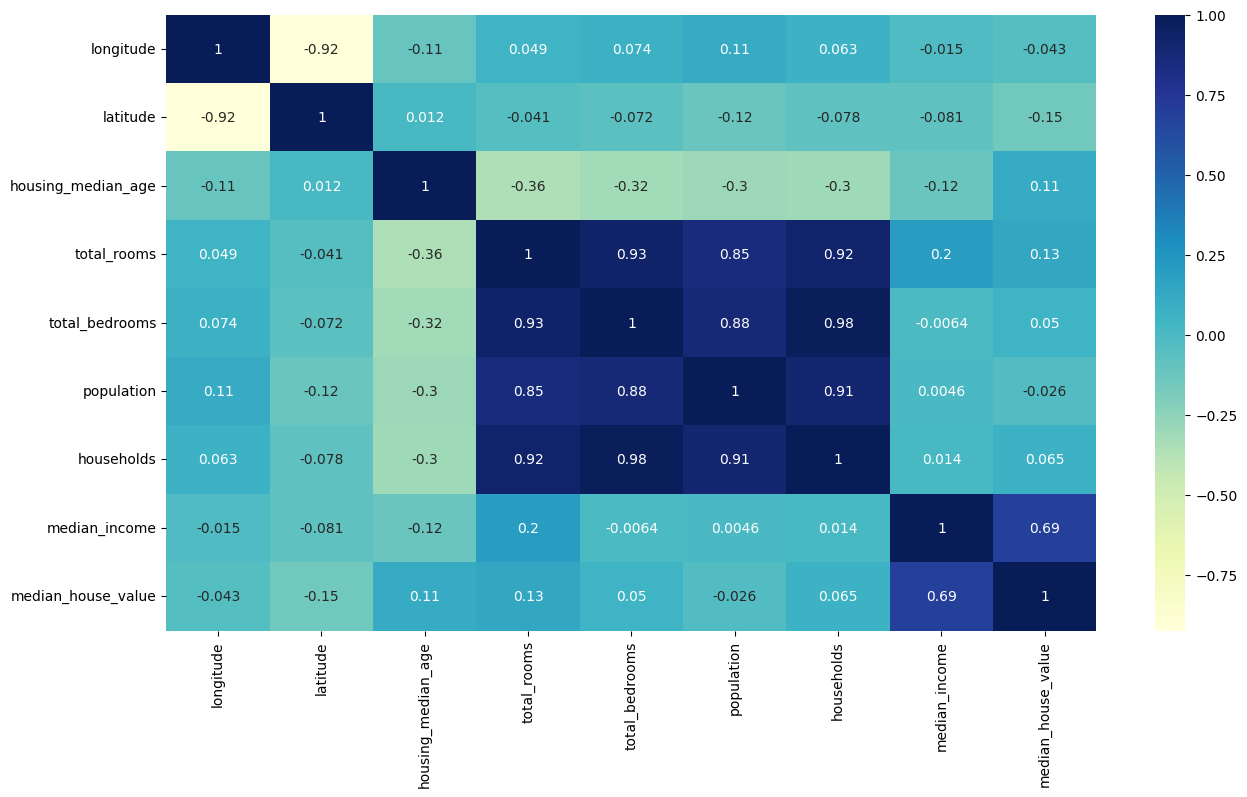

In [12]:
#Median Income correlates very well with potentially predicting median house values 
plt.figure(figsize = (15,8))
sns.heatmap(train_data.corr(numeric_only = True), annot = True, cmap = "YlGnBu")

In [13]:
train_data["total_rooms"] = np.log(train_data["total_rooms"] + 1)
train_data["total_bedrooms"] = np.log(train_data["total_bedrooms"] + 1)
train_data["population"] = np.log(train_data["population"] + 1)
train_data["households"] = np.log(train_data["households"] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

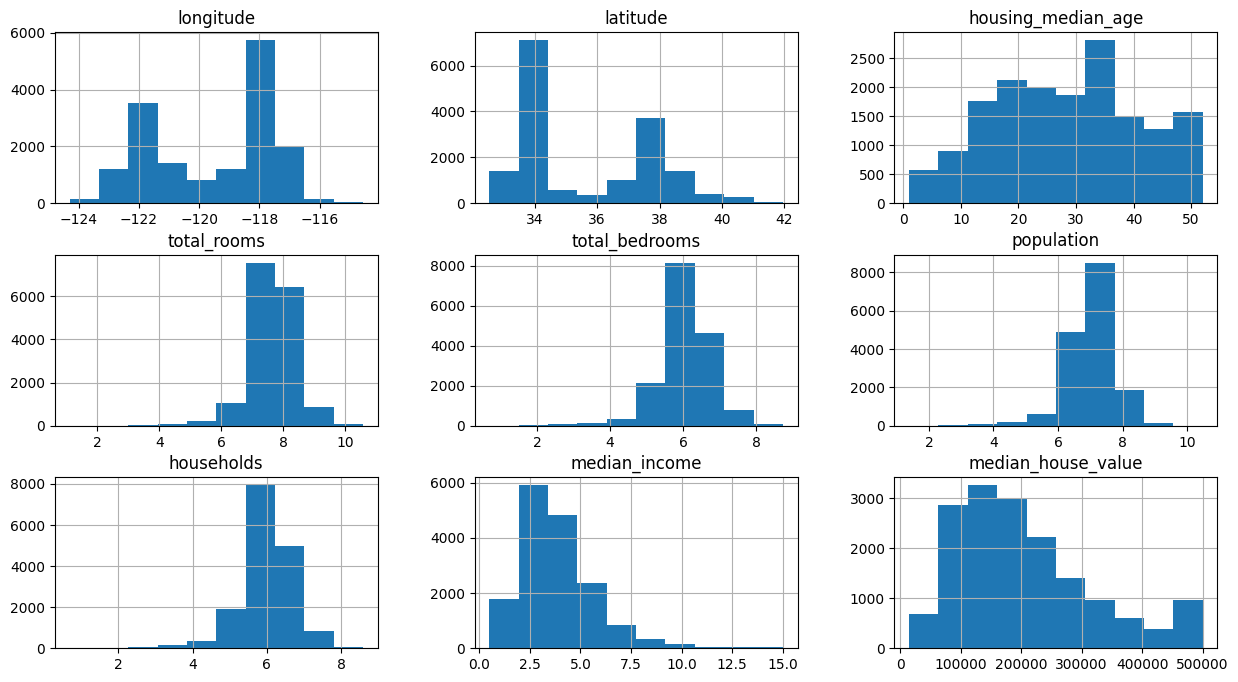

In [14]:
train_data.hist(figsize= (15,8))

In [15]:
#Starting to convert ocean_proximity column into numberic/binary values to include in our model
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7224
INLAND        5185
NEAR OCEAN    2093
NEAR BAY      1840
ISLAND           4
Name: count, dtype: int64

In [16]:
#Created new columns for each of the ocean proximity values and assigned them 1 or 0. Then dropped the ocean proximity column
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity, dtype = int)).drop(["ocean_proximity"],axis=1)

In [17]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
18096,-122.04,37.33,26.0,7.897668,5.996452,7.142827,6.063785,7.7643,474700.0,1,0,0,0,0
8481,-118.29,33.93,31.0,8.267449,6.925595,8.186186,6.870053,2.0437,137200.0,1,0,0,0,0
19348,-122.85,38.62,16.0,8.393669,6.558198,7.554335,6.548219,4.5913,244600.0,1,0,0,0,0
1682,-122.30,38.00,34.0,7.446001,5.762051,6.863803,5.834811,4.4394,162000.0,0,0,0,1,0
11986,-117.51,34.02,24.0,8.959312,7.515345,8.293299,7.476472,2.1764,135300.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2131,-119.71,36.80,17.0,7.255591,5.590987,6.759255,5.683580,3.2500,81400.0,0,1,0,0,0
14102,-117.10,32.75,16.0,7.794411,6.684612,7.317212,6.626718,1.6444,103400.0,0,0,0,0,1
18248,-122.07,37.39,37.0,7.064759,5.480639,6.380123,5.521461,5.0131,330300.0,0,0,0,1,0
14197,-117.03,32.71,34.0,7.753194,6.098074,7.429521,6.063785,3.2500,99600.0,0,0,0,0,1


<Axes: xlabel='latitude', ylabel='longitude'>

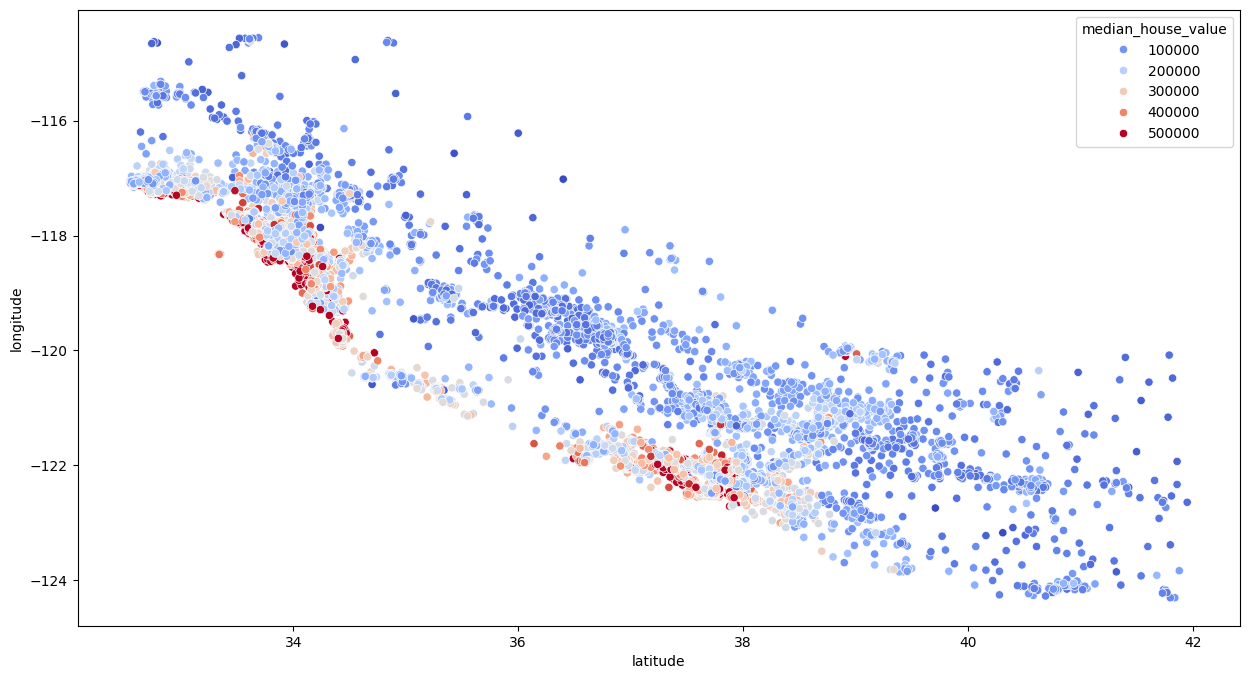

In [18]:
plt.figure(figsize = (15,8))
sns.scatterplot(x = "latitude", y = "longitude", data = train_data, hue="median_house_value", palette = "coolwarm")

In [19]:
#Creating 2 new features
train_data["bedroom_ratio"] = train_data["total_bedrooms"] / train_data["total_rooms"]
train_data["household_rooms"] = train_data["total_rooms"] / train_data["households"]

In [20]:
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
18096,-122.04,37.33,26.0,7.897668,5.996452,7.142827,6.063785,7.7643,474700.0,1,0,0,0,0,0.759269,1.302432
8481,-118.29,33.93,31.0,8.267449,6.925595,8.186186,6.870053,2.0437,137200.0,1,0,0,0,0,0.837694,1.203404
19348,-122.85,38.62,16.0,8.393669,6.558198,7.554335,6.548219,4.5913,244600.0,1,0,0,0,0,0.781327,1.281825
1682,-122.30,38.00,34.0,7.446001,5.762051,6.863803,5.834811,4.4394,162000.0,0,0,0,1,0,0.773845,1.276134
11986,-117.51,34.02,24.0,8.959312,7.515345,8.293299,7.476472,2.1764,135300.0,0,1,0,0,0,0.838831,1.198334


## Creating Linear Regression Model

In [21]:
from sklearn.linear_model import LinearRegression

#Splitting up our datasets again
x_train, y_train = train_data.drop(["median_house_value"], axis = 1), train_data["median_house_value"]

reg = LinearRegression()

reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
#Since i did feature creation and exploration after my splitting of the data, i neeed to do exactly what i did with the training data to the testing

test_data = x_test.join(y_test)

test_data["total_rooms"] = np.log(test_data["total_rooms"] + 1)
test_data["total_bedrooms"] = np.log(test_data["total_bedrooms"] + 1)
test_data["population"] = np.log(test_data["population"] + 1)
test_data["households"] = np.log(test_data["households"] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity, dtype = int)).drop(["ocean_proximity"],axis=1)

test_data["bedroom_ratio"] = test_data["total_bedrooms"] / test_data["total_rooms"]
test_data["household_rooms"] = test_data["total_rooms"] / test_data["households"]


In [23]:
x_test, y_test = test_data.drop(["median_house_value"], axis = 1), test_data["median_house_value"]

In [24]:
reg.score(x_test, y_test)

0.6854965525068963